In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('social.csv')

In [9]:
# --- Размер, типы, пропуски ---
display(df.head())
df.info()
display(df.describe())

,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Price,DistrictId
0,33,7976,5,NaN,0,184966.930730,35
1,46,10309,1,240.0,1,300009.450063,41
2,34,7759,0,229.0,1,220925.908524,53
3,23,5735,3,1084.0,0,175616.227217,58
4,35,5776,1,2078.0,2,150226.531644,99


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Social_1      10000 non-null  int64  
 1   Social_2      10000 non-null  int64  
 2   Social_3      10000 non-null  int64  
 3   Healthcare_1  5202 non-null   float64
 4   Helthcare_2   10000 non-null  int64  
 5   Price         10000 non-null  float64
 6   DistrictId    10000 non-null  int64  
dtypes: float64(2), int64(5)
memory usage: 547.0 KB


,Social_1,Social_2,Social_3,Healthcare_1,Helthcare_2,Price,DistrictId
count,10000.000000,10000.000000,10000.000000,5202.000000,10000.000000,10000.000000,10000.000000
mean,24.687000,5352.157400,8.039200,1142.904460,1.319500,214138.857399,50.400800
std,17.532614,4006.799803,23.831875,1021.517264,1.493601,92872.293865,43.587592
min,0.000000,168.000000,0.000000,0.000000,0.000000,59174.778028,0.000000
25%,6.000000,1564.000000,0.000000,350.000000,0.000000,153872.633942,20.000000
50%,25.000000,5285.000000,2.000000,900.000000,1.000000,192269.644879,36.000000
75%,36.000000,7227.000000,5.000000,1548.000000,2.000000,249135.462171,75.000000
max,74.000000,19083.000000,141.000000,4849.000000,6.000000,633233.466570,209.000000


In [10]:
missing = df.isna().sum()
print("\nПропуски:")
print(missing)


Пропуски:
Social_1           0
Social_2           0
Social_3           0
Healthcare_1    4798
Helthcare_2        0
Price              0
DistrictId         0
dtype: int64


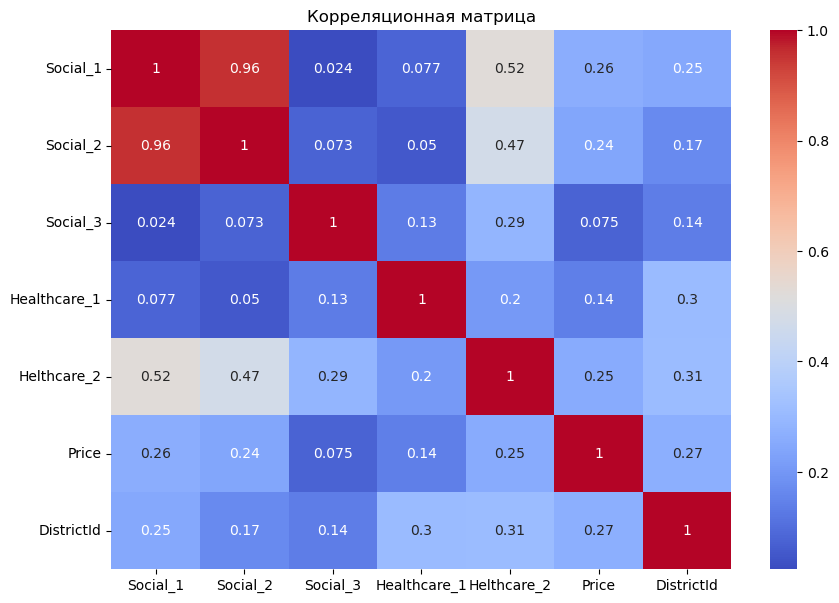

In [11]:
# --- Корреляции ---
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [12]:
# --- Анализ Healthcare_1 по районам ---
district_stats = df.groupby("DistrictId")["Healthcare_1"].describe()
display(district_stats)

,count,mean,std,min,25%,50%,75%,max
DistrictId,,,,,,,,
0,48.0,2073.583333,1069.106285,645.0,645.0,2857.0,2857.0,2857.0
1,57.0,228.771930,18.133451,200.0,200.0,240.0,240.0,240.0
2,59.0,1435.254237,761.125201,900.0,900.0,990.0,2620.0,2620.0
3,82.0,644.146341,910.820009,30.0,30.0,30.0,1937.0,2715.0
4,11.0,2082.909091,570.562784,1046.0,1940.0,2500.0,2500.0,2500.0
...,...,...,...,...,...,...,...,...
202,2.0,4702.000000,0.000000,4702.0,4702.0,4702.0,4702.0,4702.0
205,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207,1.0,1815.000000,NaN,1815.0,1815.0,1815.0,1815.0,1815.0


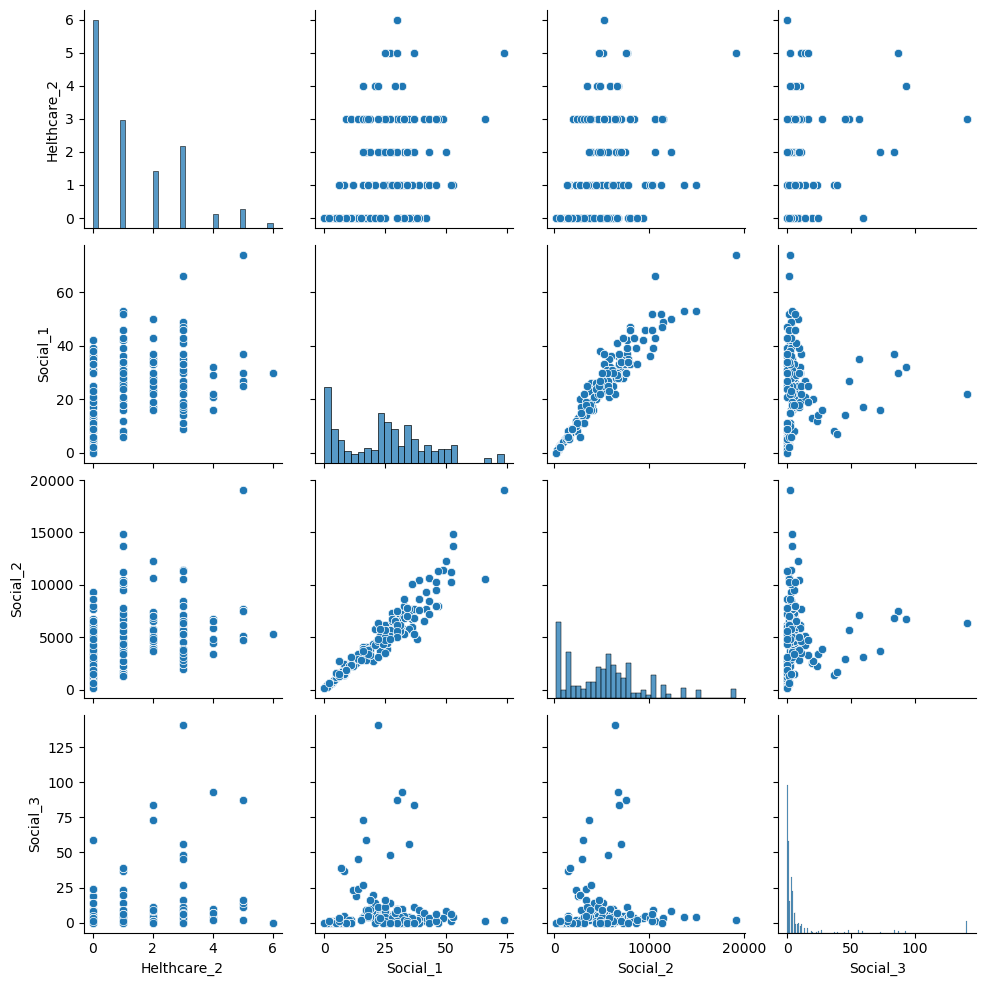

In [13]:
# --- Проверка связи Healthcare_2 ↔ Social_1/2/3 ---
sns.pairplot(df[["Helthcare_2", "Social_1", "Social_2", "Social_3"]])
plt.show()